In [9]:
from admm_colin.admmcolinviz import ADMMColin
from relax_and_round_smooth.fenicsviz import fenicsModel
from matplotlib import pyplot as plt
import numpy as np
import h5py
from admm_colin.admmcolinviz import _transpose_control_triangles
import math
from pathlib import Path

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [10]:
# import networkx as nx
# import math

# def build_graph(n_x: int, n_y: int):
#     """Graph builder from the provided TV reference."""
#     N = n_x * n_y
#     graph = nx.Graph()
#     graph.add_nodes_from(range(N))

#     for k in range(0, N, 2):
#         if k + 1 < N:
#             graph.add_edge(k, k + 1)
#         if (k + 2) % n_y != 0 and k + 3 < N:
#             graph.add_edge(k, k + 3)
#         if (k // n_y) != 0:
#             nb = k - (n_y - 1)
#             if nb >= 0:
#                 graph.add_edge(k, nb)

#     return graph


# def build_scale(graph: nx.Graph):
#     scale = np.zeros(len(graph.edges()), dtype=float)
#     for k, (u, v) in enumerate(graph.edges()):
#         scale[k] = math.sqrt(2.0) if abs(int(u) - int(v)) == 1 else 1.0
#     return scale


# def compute_tv(control: np.ndarray, graph: nx.Graph, scale: np.ndarray) -> float:
#     diffs = []
#     for (u, v), s in zip(graph.edges(), scale):
#         diffs.append(s * abs(control[u] - control[v]))
#     return float(sum(diffs))


# graph = build_graph(64, 2*64)
# scale = build_scale(graph)
# tv_colin = compute_tv(colin_control, graph, scale)
# tv_oc = compute_tv(oc_control_disc, graph, scale)
# print("OC TV:", tv_oc)
# print("colin TV:", tv_colin)

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py


def _safe_sorted_dirs(path):
    names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    try:
        return sorted(names, key=lambda x: float(x))
    except ValueError:
        return sorted(names)


def _last_value(x):
    arr = np.asarray(x, dtype=float)
    if arr.size == 0:
        raise ValueError("Empty dataset")
    return float(arr.reshape(-1)[-1])

In [12]:
# ----------------------------
# ADMM loader (via ADMMColin)
# ----------------------------
def load_admm_runs(base_dir="admm_colin/run_data_admm_gurobi"):
    rows = []

    for alpha_name in _safe_sorted_dirs(base_dir):
        alpha_path = os.path.join(base_dir, alpha_name)
        alpha = float(alpha_name)

        for fname in sorted(os.listdir(alpha_path)):
            if not fname.endswith(".h5"):
                continue

            dim = int(os.path.splitext(fname)[0])
            try:
                admm = ADMMColin(alpha=alpha, dim=dim, base_dir=base_dir)
                series = admm.trial(0).series

                compliance = _last_value(series.compliance_disc)
                perimeter = _last_value(series.tv_disc)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "admm",
                        "path": os.path.join(alpha_path, fname),
                    }
                )
            except Exception as exc:
                print(f"Skipped ADMM file {os.path.join(alpha_path, fname)}: {exc}")

    return pd.DataFrame(rows)

In [13]:
# ----------------------------
# ADMM loader (via ADMMColin)
# ----------------------------
def load_admm_mip_runs(base_dir="admm_colin/run_data_admm_gurobi_mip"):
    rows = []

    for alpha_name in _safe_sorted_dirs(base_dir):
        alpha_path = os.path.join(base_dir, alpha_name)
        alpha = float(alpha_name)

        for fname in sorted(os.listdir(alpha_path)):
            if not fname.endswith(".h5"):
                continue

            dim = int(os.path.splitext(fname)[0])
            try:
                admm = ADMMColin(alpha=alpha, dim=dim, base_dir=base_dir)
                series = admm.trial(0).series

                compliance = _last_value(series.compliance_disc)
                perimeter = _last_value(series.tv_disc)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "admm",
                        "path": os.path.join(alpha_path, fname),
                    }
                )
            except Exception as exc:
                print(f"Skipped ADMM file {os.path.join(alpha_path, fname)}: {exc}")

    return pd.DataFrame(rows)

In [14]:
# ---------------------------------------
# OC loader (direct root-dataset reading)
# ---------------------------------------
def load_oc_runs(base_dir="oc_method/OC_results_new"):
    rows = []

    for r_name in _safe_sorted_dirs(base_dir):
        r_path = os.path.join(base_dir, r_name)
        r_val = float(r_name)

        for fname in sorted(os.listdir(r_path)):
            if not fname.endswith(".h5"):
                continue

            h5_path = os.path.join(r_path, fname)
            dim = int(os.path.splitext(fname)[0])

            try:
                with h5py.File(h5_path, "r") as f:
                    #control_disc = f["control_disc"][()]
                    #control_disc_T = _transpose_control_triangles(control_disc, dim)
                    #perimeter = compute_tv(control_disc_T, graph, scale)
                    perimeter = _last_value(f["tv_disc"])
                    compliance = _last_value(f["compliance_disc"])

                rows.append(
                    {
                        "r": r_val,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "oc",
                        "path": h5_path,
                    }
                )
            except Exception as exc:
                print(f"Skipped OC file {h5_path}: {exc}")

    return pd.DataFrame(rows)

In [15]:
# ---------------------------------------
# R&R loader (direct root-dataset reading)
# ---------------------------------------
def load_fenics_runs(base_dir="relax_and_round_smooth/fenics_model_tri_1e-06"):
    rows = []
    base_path = Path(base_dir)

    for alpha_name in _safe_sorted_dirs(base_path):
        alpha = float(alpha_name)
        alpha_path = base_path / alpha_name

        for file_path in sorted(alpha_path.glob("*.h5")):
            dim = int(file_path.stem)
            try:
                with h5py.File(file_path, "r") as h5f:
                    summary = h5f["summary"]
                    disc_tv = float(summary["disc_TV"][()])
                    compliance = float(summary["disc_compliance"][()])
                    runtime_total = float(summary.attrs.get("runtime_total", np.nan))

                perimeter = disc_tv / float(alpha)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "runtime_total": runtime_total,
                        "source": "fenics",
                        "path": str(file_path),
                    }
                )
            except Exception as exc:
                print(f"Skipped FEniCS file {file_path}: {exc}")

    return pd.DataFrame(rows)

In [16]:
admm_df = load_admm_runs(base_dir="admm_colin/run_data_admm_gurobi")
admm_mip_df = load_admm_mip_runs(base_dir="admm_colin/run_data_admm_gurobi_mip")
oc_df = load_oc_runs(base_dir="oc_method/OC_results_new")
fenics_df = load_fenics_runs(base_dir="relax_and_round_smooth/fenics_model_tri_1e-06")

print(f"Loaded ADMM points: {len(admm_df)}")
print(f"Loaded ADMM MIP points: {len(admm_mip_df)}")
print(f"Loaded OC points: {len(oc_df)}")
print(f"Loaded FEniCS points: {len(fenics_df)}")

if admm_df.empty:
    print("ADMM dataframe is empty. Check run_data_admm_gurobi.")
elif admm_mip_df.empty:
    print("ADMM MIP dataframe is empty. Check run_data_admm_gurobi_mip.")
elif oc_df.empty:
    print("OC dataframe is empty. Check OC_results.")
elif fenics_df.empty:
    print("FEniCS dataframe is empty. Check fenics_model_tri.")
else:
    # Build non-overlapping bins of width 50, starting from the ADMM minimum perimeter.
    admm_perimeter_min = float(admm_df["perimeter"].min())
    admm_perimeter_max = float(admm_df["perimeter"].max())

    bin_width = 50.0
    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width

    # Drop the last bin if it would extend past the ADMM max perimeter.
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)

    centers = 0.5 * (bin_starts + bin_ends)

    print(
        f"Using {len(centers)} non-overlapping bins of width {bin_width:.1f} "
        f"from {admm_perimeter_min:.2f} to {admm_perimeter_max:.2f}"
    )

    BIN_COLOR = "tab:blue"
    BIN_FILL_ALPHA = 0.12
    BIN_EDGE_ALPHA = 0.70

    
    df_admm = admm_df.copy()
    df_admm_mip = admm_mip_df.copy()
    df_oc = oc_df.copy()
    df_fenics = fenics_df.copy()

Loaded ADMM points: 30
Loaded ADMM MIP points: 47
Loaded OC points: 160
Loaded FEniCS points: 42
Using 72 non-overlapping bins of width 50.0 from 151.83 to 3761.55


In [17]:
import numpy as np
import pandas as pd

max_points_per_bin = 6
seed = 0

# Reuse existing bins if available; otherwise rebuild from ADMM perimeter range.
if "bin_starts" not in globals() or "bin_ends" not in globals():
    if "admm_df" not in globals() or admm_df.empty:
        raise ValueError("admm_df is not available. Run the ADMM/OC loading cell first.")

    admm_perimeter_min = float(admm_df["perimeter"].min())
    admm_perimeter_max = float(admm_df["perimeter"].max())
    bin_width = 50.0

    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)


def cap_points_per_bin(df, bin_starts, bin_ends, max_points=6, seed=0):
    if df.empty:
        return df.copy()

    rng = np.random.default_rng(seed)
    capped_parts = []

    for left_edge, right_edge in zip(bin_starts, bin_ends):
        in_bin = df[(df["perimeter"] >= left_edge) & (df["perimeter"] < right_edge)]

        if len(in_bin) > max_points:
            keep_idx = rng.choice(in_bin.index.to_numpy(), size=max_points, replace=False)
            in_bin = in_bin.loc[np.sort(keep_idx)]

        capped_parts.append(in_bin)

    if not capped_parts:
        return df.iloc[0:0].copy()

    capped_df = pd.concat(capped_parts, axis=0)
    return capped_df.reset_index(drop=True)


if "admm_df" not in globals() or "oc_df" not in globals():
    raise ValueError("admm_df or oc_df missing. Run the plotting/data loading cell first.")

admm_df_capped = cap_points_per_bin(admm_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed)
admm_mip_df_capped = cap_points_per_bin(admm_mip_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed + 1)
oc_df_capped = cap_points_per_bin(oc_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed + 1)
fenics_df_capped = cap_points_per_bin(fenics_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed + 2)

# Verification: each bin should have <= max_points_per_bin for both methods.
admm_bin_counts = []
admm_mip_bin_counts = []
oc_bin_counts = []
fenics_bin_counts = []

for left_edge, right_edge in zip(bin_starts, bin_ends):
    admm_count = int(((admm_df_capped["perimeter"] >= left_edge) & (admm_df_capped["perimeter"] < right_edge)).sum())
    oc_count = int(((oc_df_capped["perimeter"] >= left_edge) & (oc_df_capped["perimeter"] < right_edge)).sum())
    admm_bin_counts.append(admm_count)
    admm_mip_count = int(((admm_mip_df_capped["perimeter"] >= left_edge) & (admm_mip_df_capped["perimeter"] < right_edge)).sum())
    admm_mip_bin_counts.append(admm_mip_count)
    oc_bin_counts.append(oc_count)
    fenics_count = int(((fenics_df_capped["perimeter"] >= left_edge) & (fenics_df_capped["perimeter"] < right_edge)).sum())
    fenics_bin_counts.append(fenics_count)

print("ADMM counts per bin (capped):", admm_bin_counts)
print("ADMM MIP counts per bin (capped):", admm_mip_bin_counts)
print("OC counts per bin (capped):", oc_bin_counts)
print("FEniCS counts per bin (capped):", fenics_bin_counts)
print("ADMM max count:", max(admm_bin_counts) if admm_bin_counts else 0)
print("ADMM MIP max count:", max(admm_mip_bin_counts) if admm_mip_bin_counts else 0)
print("OC max count:", max(oc_bin_counts) if oc_bin_counts else 0)
print("FEniCS max count:", max(fenics_bin_counts) if fenics_bin_counts else 0)
print("Total ADMM points after cap:", len(admm_df_capped))
print("Total ADMM MIP points after cap:", len(admm_mip_df_capped))
print("Total OC points after cap:", len(oc_df_capped))
print("Total FEniCS points after cap:", len(fenics_df_capped))

ADMM counts per bin (capped): [4, 2, 2, 1, 5, 5, 2, 3, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ADMM MIP counts per bin (capped): [2, 2, 2, 4, 3, 2, 5, 4, 3, 0, 3, 2, 4, 2, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
OC counts per bin (capped): [6, 6, 6, 6, 6, 6, 6, 6, 2, 1, 4, 4, 6, 1, 3, 3, 1, 1, 1, 0, 0, 2, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
FEniCS counts per bin (capped): [0, 1, 4, 2, 5, 2, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ADMM max

In [18]:
ADMM_SMALL_PERI_MIN=160
ADMM_SMALL_PERI_MAX=170
ADMM_MIP_SMALL_PERI_MIN=160
ADMM_MIP_SMALL_PERI_MAX=170
OC_SMALL_PERI_MIN=160
OC_SMALL_PERI_MAX=170
FENICS_SMALL_PERI_MIN=165
FENICS_SMALL_PERI_MAX=170


ADMM_MEDIUM_PERI_MIN=315
ADMM_MEDIUM_PERI_MAX=325
ADMM_MIP_MEDIUM_PERI_MIN=315
ADMM_MIP_MEDIUM_PERI_MAX=325
OC_MEDIUM_PERI_MIN=315
OC_MEDIUM_PERI_MAX=318
FENICS_MEDIUM_PERI_MIN=315
FENICS_MEDIUM_PERI_MAX=318


ADMM_LARGE_PERI_MIN=520
ADMM_LARGE_PERI_MAX=530
ADMM_MIP_LARGE_PERI_MIN=520
ADMM_MIP_LARGE_PERI_MAX=535
OC_LARGE_PERI_MIN=520
OC_LARGE_PERI_MAX=530
FENICS_LARGE_PERI_MIN=520
FENICS_LARGE_PERI_MAX=535

Using 9 non-overlapping bins of width 50.0 from 151.83 to 648.17


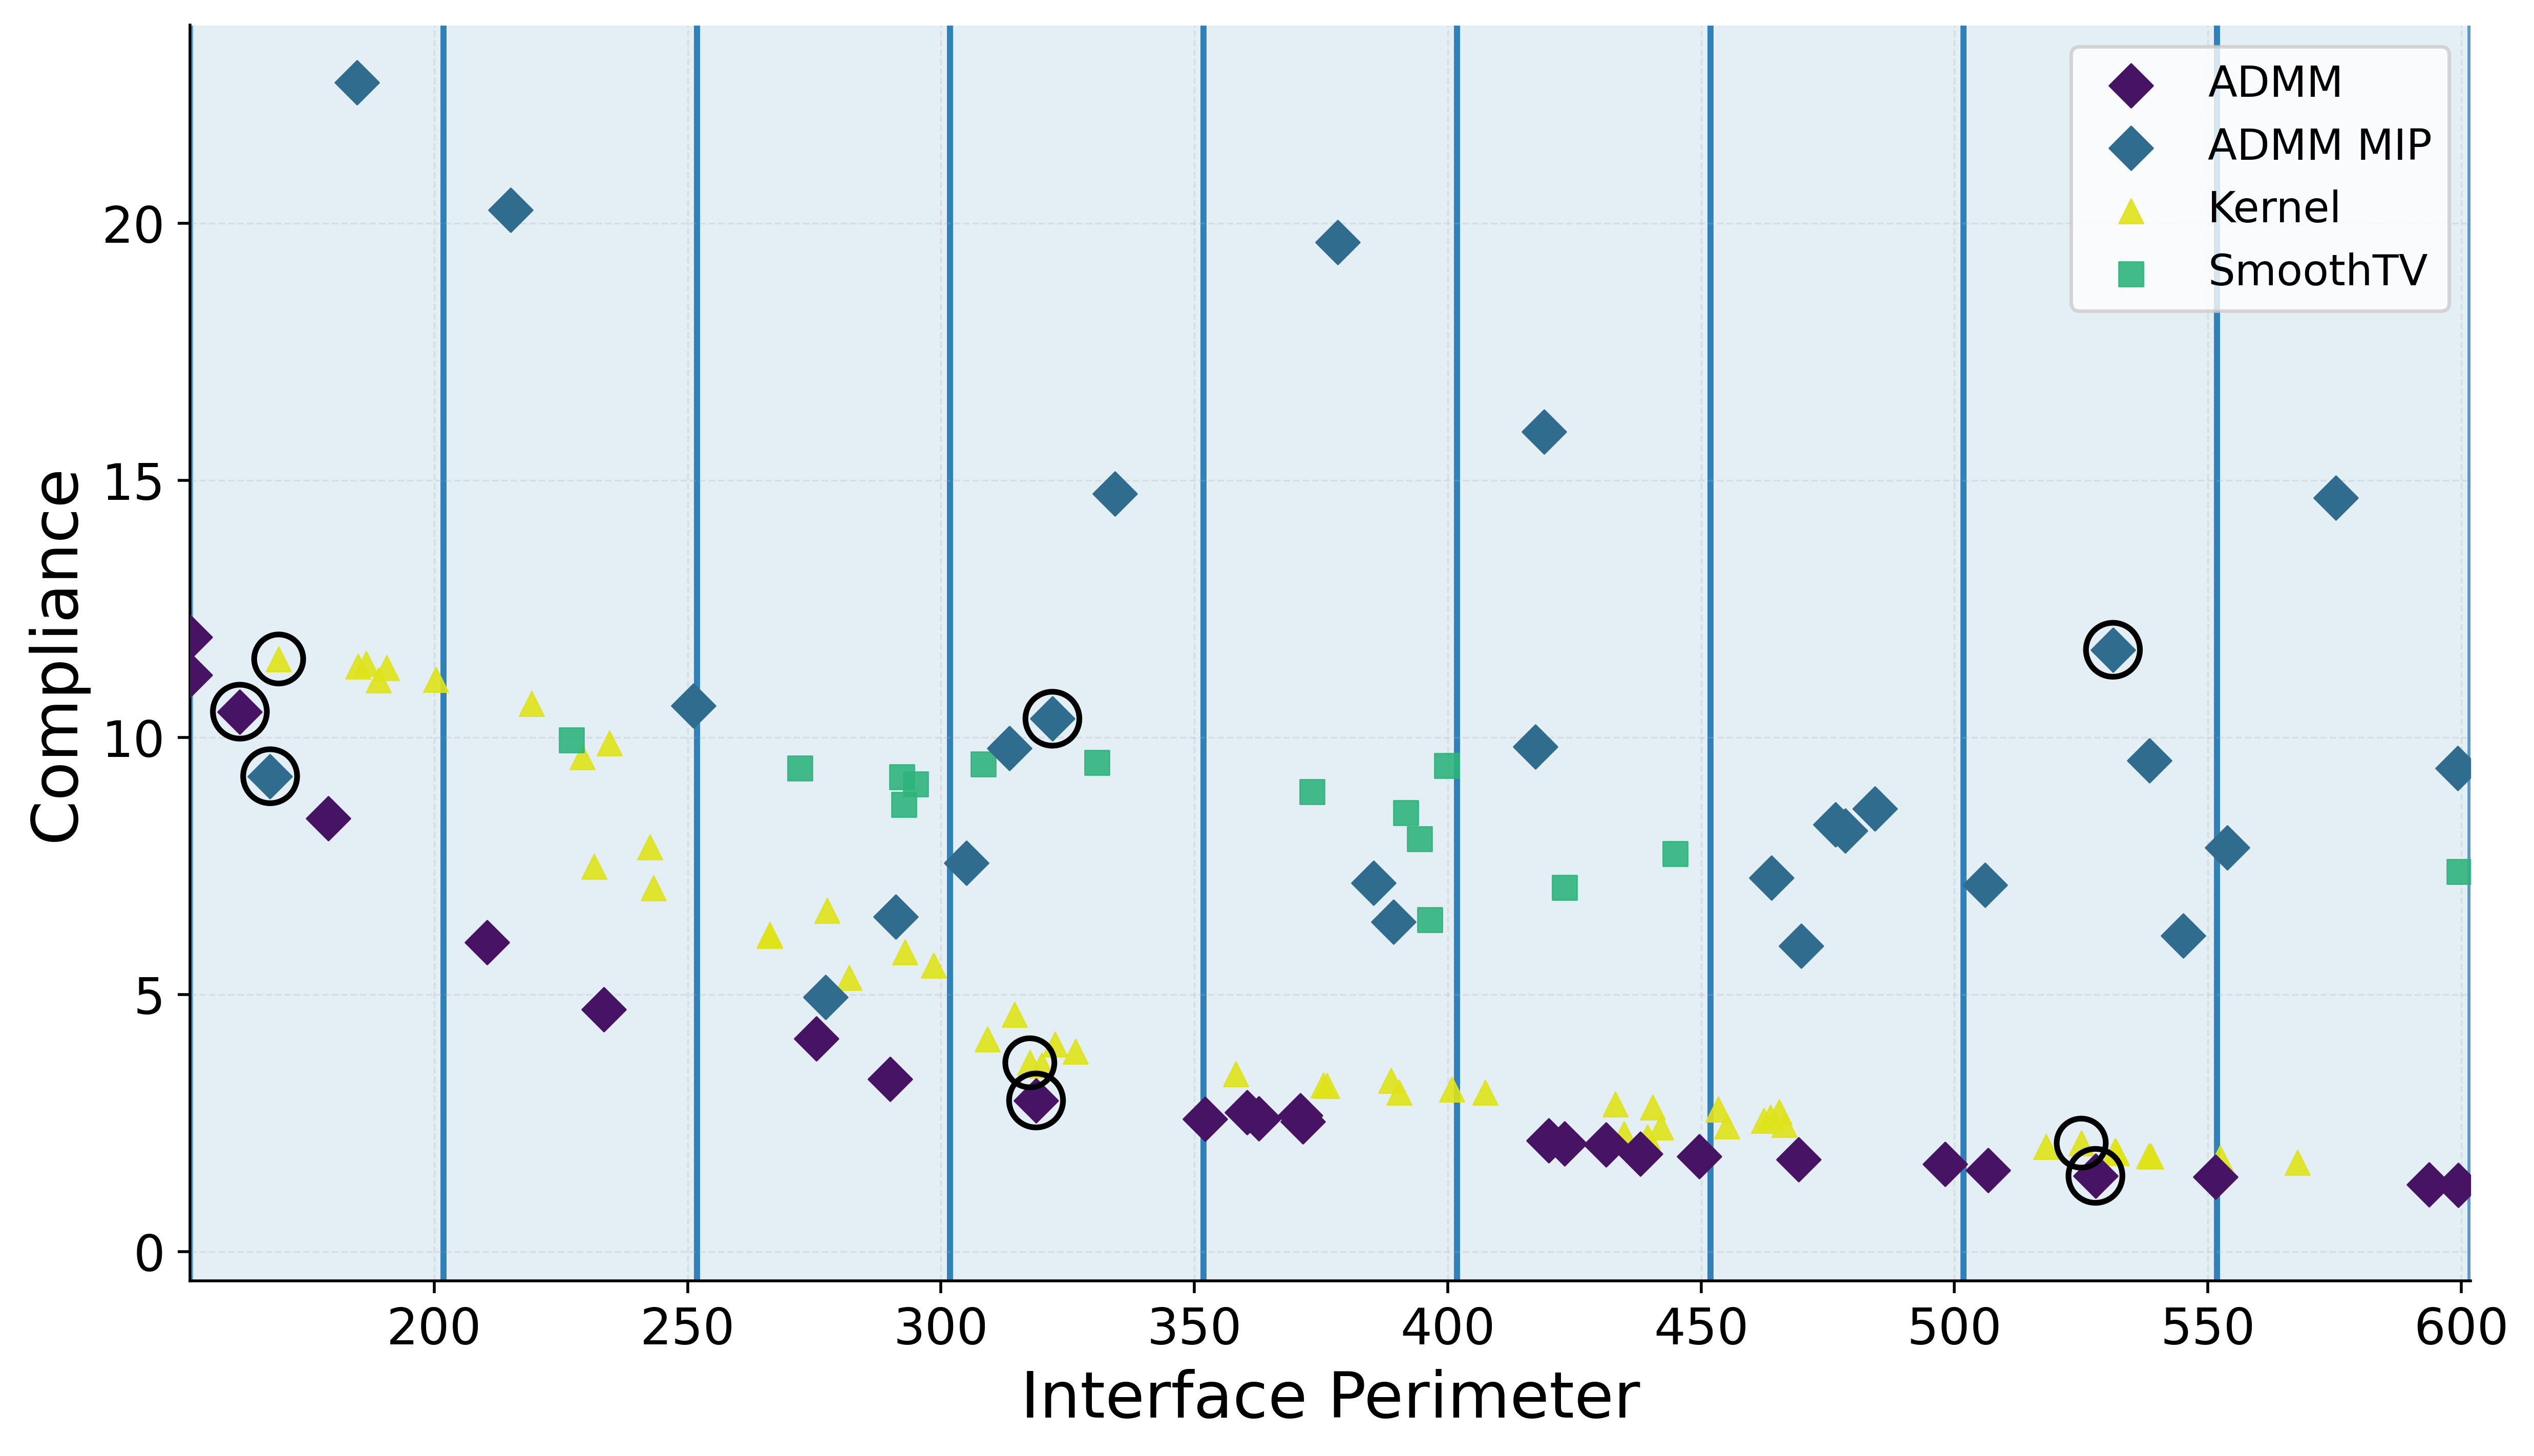

In [19]:
def circle_points(ax, df, mask, x="perimeter", y="compliance",
                  size=220, color="black", label=None, zorder=10):
    ax.scatter(
        df.loc[mask, x],
        df.loc[mask, y],
        marker="o",
        s=size,
        facecolors="none",
        edgecolors=color,
        linewidths=1.6,
        label=label,
        zorder=zorder,
    )

if admm_df_capped.empty:
    print("ADMM dataframe is empty. Check run_data_admm_gurobi.")
elif admm_mip_df_capped.empty:
    print("ADMM MIP dataframe is empty. Check run_data_admm_gurobi_mip.")
elif oc_df_capped.empty:
    print("OC dataframe is empty. Check OC_results.")
elif fenics_df_capped.empty:
    print("FEniCS dataframe is empty. Check fenics_model_tri.")
else:
    # Build non-overlapping bins of width 50, starting from the ADMM minimum perimeter.
    admm_perimeter_min = float(admm_df_capped["perimeter"].min())
    admm_perimeter_max = float(admm_df_capped["perimeter"].max())

    bin_width = 50.0
    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width

    # Drop the last bin if it would extend past the ADMM max perimeter.
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)

    centers = 0.5 * (bin_starts + bin_ends)

    print(
        f"Using {len(centers)} non-overlapping bins of width {bin_width:.1f} "
        f"from {admm_perimeter_min:.2f} to {admm_perimeter_max:.2f}"
    )

    BIN_COLOR = "tab:blue"
    BIN_FILL_ALPHA = 0.12
    BIN_EDGE_ALPHA = 0.70

    cmap = plt.cm.viridis
    admm_color     = cmap(0.05)  # dark purple
    admm_mip_color = cmap(0.35)  # blue
    fenics_color   = cmap(0.65)  # green
    kernel_color   = cmap(0.95)  # yellow
    highlight_color = "black"   # clean circle color

    fig, ax = plt.subplots(figsize=(10, 6.5))

    # Clearly visible bins: filled rectangles and solid boundaries in the same color.
    for left_edge, right_edge in zip(bin_starts, bin_ends):
        ax.axvspan(left_edge, right_edge, color=BIN_COLOR, alpha=BIN_FILL_ALPHA, zorder=0, linewidth=0)
        ax.axvline(left_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)
        ax.axvline(right_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)

    # ADMM: diamonds
    sc1 = ax.scatter(
        admm_df_capped["perimeter"],
        admm_df_capped["compliance"],
        marker="D",
        s=75,
        #color="#e74c3c",
        color=admm_color,
        #edgecolors="black",
        linewidth=0.5,
        label="ADMM",
        zorder=4,
    )

    sc2 = ax.scatter(
            admm_mip_df_capped["perimeter"],
            admm_mip_df_capped["compliance"],
            marker="D",
            s=75,
            #color="#e74c3c",
            color=admm_mip_color,
            #edgecolors="black",
            linewidth=0.5,
            label="ADMM MIP",
            zorder=4,
        )


    # Kernel/OC: teal markers
    sc3 = ax.scatter(
        oc_df_capped["perimeter"],
        oc_df_capped["compliance"],
        marker="^",
        s=48,
        #color="teal",
        color=kernel_color,
        #edgecolors="black",
        linewidth=0.4,
        alpha=0.9,
        label="Kernel",
        zorder=3,
    )

    # Kernel/OC: teal markers
    sc4 = ax.scatter(
        fenics_df_capped["perimeter"],
        fenics_df_capped["compliance"],
        marker="s",
        s=48,
        #color="teal",
        color=fenics_color,
        #edgecolors="black",
        linewidth=0.4,
        alpha=0.9,
        label="SmoothTV",
        zorder=3,
    )


    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    ax.legend(frameon=True, fontsize=12)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # condition for marking points of interest
    admm_mask = (((admm_df_capped["perimeter"] > ADMM_SMALL_PERI_MIN) & (admm_df_capped["perimeter"] < ADMM_SMALL_PERI_MAX)) 
                 | ((admm_df_capped["perimeter"] > ADMM_MEDIUM_PERI_MIN) & (admm_df_capped["perimeter"] < ADMM_MEDIUM_PERI_MAX))
                 | ((admm_df_capped["perimeter"] > ADMM_LARGE_PERI_MIN) & (admm_df_capped["perimeter"] < ADMM_LARGE_PERI_MAX)))

    admm_mip_mask = (((admm_mip_df_capped["perimeter"] > ADMM_MIP_SMALL_PERI_MIN) & (admm_mip_df_capped["perimeter"] < ADMM_MIP_SMALL_PERI_MAX)) 
                     | ((admm_mip_df_capped["perimeter"] > ADMM_MIP_MEDIUM_PERI_MIN) & (admm_mip_df_capped["perimeter"] < ADMM_MIP_MEDIUM_PERI_MAX))
                     | ((admm_mip_df_capped["perimeter"] > ADMM_MIP_LARGE_PERI_MIN) & (admm_mip_df_capped["perimeter"] < ADMM_MIP_LARGE_PERI_MAX)))


    oc_mask = (((oc_df_capped["perimeter"] > OC_SMALL_PERI_MIN) & (oc_df_capped["perimeter"] < OC_SMALL_PERI_MAX))
               | ((oc_df_capped["perimeter"] > OC_MEDIUM_PERI_MIN) & (oc_df_capped["perimeter"] < OC_MEDIUM_PERI_MAX))
               | ((oc_df_capped["perimeter"] > OC_LARGE_PERI_MIN) & (oc_df_capped["perimeter"] < OC_LARGE_PERI_MAX)))

    fenics_mask = (((fenics_df_capped["perimeter"] > FENICS_SMALL_PERI_MIN) & (fenics_df_capped["perimeter"] < FENICS_SMALL_PERI_MAX))
                   | ((fenics_df_capped["perimeter"] > FENICS_MEDIUM_PERI_MIN) & (fenics_df_capped["perimeter"] < FENICS_MEDIUM_PERI_MAX))
                   | ((fenics_df_capped["perimeter"] > FENICS_LARGE_PERI_MIN) & (fenics_df_capped["perimeter"] < FENICS_LARGE_PERI_MAX)))
    

    circle_points(
    ax,
    admm_df_capped,
    admm_mask,
    size=230,
    color="black",
    label="Selected ADMM"
    )

    circle_points(
        ax,
        admm_mip_df_capped,
        admm_mip_mask,
        size=230,
        color="black",
        label="Selected ADMM MIP"
    )


    circle_points(
        ax,
        oc_df_capped,
        oc_mask,
        size=190,
        color="black",
        label="Selected Kernel"
    )

    circle_points(
        ax,
        fenics_df_capped,
        fenics_mask,
        size=190,
        color="black",
        label="Selected FEniCS"
    )


    
    # Bin count annotations just above the plot area.
    y_top = max(admm_df_capped["compliance"].max(), oc_df_capped["compliance"].max())
    y_bot = min(admm_df_capped["compliance"].min(), oc_df_capped["compliance"].min())
    y_text = y_top + 0.02 * (y_top - y_bot)

    for c, left_edge, right_edge in zip(centers, bin_starts, bin_ends):
        in_bin = (oc_df_capped["perimeter"] >= left_edge) & (oc_df_capped["perimeter"] < right_edge)
        n = int(in_bin.sum())
        # ax.text(c, y_text, str(n), ha="center", va="bottom", fontsize=8, color=BIN_COLOR, alpha=0.85)

    # Neutral labels and ticks (no color coding)
    ax.set_xlabel("Interface Perimeter", fontsize=18)
    ax.set_ylabel("Compliance", fontsize=18)
    ax.set_xlim(admm_perimeter_min, bin_ends[-1])
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.tick_params(axis="both", which="minor", labelsize=12)
    ax.grid(True, alpha=0.25)

    # Use actual scatter handles so legend marker shapes/colors are correct.
    handles = [sc1, sc2]
    labels = [h.get_label() for h in handles]
    # fig.legend(
    #     handles,
    #     labels,
    #     loc="upper center",
    #     bbox_to_anchor=(0.52, 1.05),
    #     ncol=2,
    #     frameon=True,
    #     fontsize=13,
    #     markerscale=1.3,
    # )

    plt.tight_layout(rect=(0, 0.11, 1, 1))
    plt.gcf().set_dpi(500)
    plt.show()

    df_admm = admm_df_capped.copy()
    df_oc = oc_df_capped.copy()

In [20]:
admm_df["mark"] = 0
admm_df["color"] = None
oc_df["mark"] = 0
oc_df["color"] = None
fenics_df["mark"] = 0
fenics_df["color"] = None

In [21]:
admm_condition = ((admm_df_capped["perimeter"])>350) & ((admm_df_capped["perimeter"])<400)
admm_df_capped.loc[admm_condition]

,alpha,dim,perimeter,compliance,source,path
9,0.0180,64,362.710678,2.588212,admm,admm_colin/run_data_admm_gurobi/0.018/64.h5
10,0.0182,64,360.367532,2.709431,admm,admm_colin/run_data_admm_gurobi/0.0182/64.h5
11,0.0186,64,370.911688,2.652744,admm,admm_colin/run_data_admm_gurobi/0.0186/64.h5
12,0.0194,64,371.396970,2.531212,admm,admm_colin/run_data_admm_gurobi/0.0194/64.h5
13,0.0200,64,352.083261,2.584188,admm,admm_colin/run_data_admm_gurobi/0.02/64.h5


In [22]:
admm_condition = ((admm_df_capped["perimeter"])>ADMM_MEDIUM_PERI_MIN) & ((admm_df_capped["perimeter"])<ADMM_MEDIUM_PERI_MAX)
admm_df_capped.loc[admm_condition, "mark"] = 1
admm_df_capped.loc[admm_condition, "color"] = "black"
alpha_admm = admm_df_capped[admm_condition]["alpha"].values[0]

In [23]:
admm_mip_condition = ((admm_mip_df_capped["perimeter"])>ADMM_MIP_MEDIUM_PERI_MIN) & ((admm_mip_df_capped["perimeter"])<ADMM_MIP_MEDIUM_PERI_MAX)
admm_mip_df_capped.loc[admm_mip_condition, "mark"] = 1
admm_mip_df_capped.loc[admm_mip_condition, "color"] = "black"
alpha_admm_mip = admm_mip_df_capped[admm_mip_condition]["alpha"].values[0]

In [24]:
oc_condition = ((oc_df_capped["perimeter"])>OC_MEDIUM_PERI_MIN) & ((oc_df_capped["perimeter"])<OC_MEDIUM_PERI_MAX)
oc_df_capped.loc[oc_condition, "mark"] = 1
oc_df_capped.loc[oc_condition, "color"] = "black"
r = oc_df_capped[oc_condition]["r"].values[0]

In [25]:
fenics_condition = ((fenics_df_capped["perimeter"])>FENICS_MEDIUM_PERI_MIN) & ((fenics_df_capped["perimeter"])<FENICS_MEDIUM_PERI_MAX)
fenics_df_capped.loc[fenics_condition, "mark"] = 1
fenics_df_capped.loc[fenics_condition, "color"] = "black"
alpha_fenics = fenics_df_capped[fenics_condition]["alpha"].values[0]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [45]:
admmcolin = ADMMColin(alpha=alpha_admm, dim=64, base_dir="admm_colin/run_data_admm_gurobi")
colin_control = admmcolin.trial(0).iters.control_disc[-1]

In [46]:
admmmip = ADMMColin(alpha=alpha_admm_mip, dim=64, base_dir="admm_colin/run_data_admm_gurobi_mip")
mip_control = admmmip.trial(0).iters.control_disc[-1]

In [55]:
print(alpha_admm, alpha_admm_mip, r, alpha_fenics)

0.019 0.045 7.04 0.019


In [53]:
admmoc = ADMMColin(alpha=0.019, dim=64, base_dir="admm_colin/run_data_admm_gurobi")
from pathlib import Path
r_value = r
mesh_dim = 64
results_root=Path("oc_method/OC_results_new")
folder = results_root / f"{float(r):.2f}"
file_path = folder / f"{mesh_dim}.h5"

if not file_path.exists():
    print(f"Run file not found: {file_path}")

with h5py.File(file_path, "r") as h5f:
    oc_control = h5f["control_cont"][()]
    oc_control_disc = h5f["control_disc"][()]
    #oc_control_disc_T = _transpose_control_triangles(oc_control_disc, 64)
    oc_r_attr = float(h5f.attrs.get("r", r_value))
    oc_tv_disc = float(h5f["tv_disc"][()])
    oc_compliance_disc = float(h5f["compliance_disc"][()])

In [54]:
print(r)

7.04


In [48]:
fenics = fenicsModel(alpha=alpha_fenics, n=64, base_dir="relax_and_round_smooth/fenics_model_tri_1e-06")
fenics_control = fenics.control.vector().get_local()


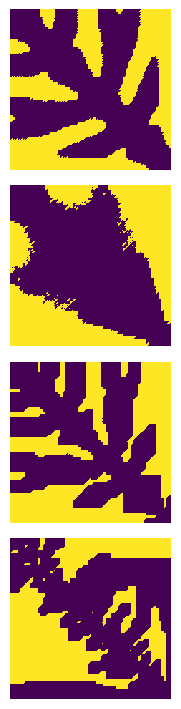

In [40]:
fig, ax = plt.subplots(figsize=(4, 7.2), nrows=4, ncols=1)
admmcolin.plot_control(oc_control_disc, ax=ax[0])
admmcolin.plot_control(fenics_control, ax=ax[1])
admmcolin.plot_control(colin_control, ax=ax[2])
admmcolin.plot_control(mip_control, ax=ax[3])
#plt.gcf().set_dpi(500)
plt.tight_layout()


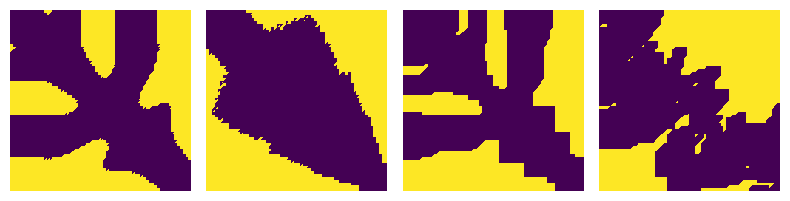

In [49]:
fig, ax = plt.subplots(figsize=(8, 4), nrows=1, ncols=4)
admmcolin.plot_control(oc_control_disc, ax=ax[0])
admmcolin.plot_control(fenics_control, ax=ax[1])
admmcolin.plot_control(colin_control, ax=ax[2])
admmcolin.plot_control(mip_control, ax=ax[3])
#plt.gcf().set_dpi(500)
plt.tight_layout()


In [ ]:
from pathlib import Path


def _safe_sorted_dirs(path):
    names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    try:
        return sorted(names, key=lambda x: float(x))
    except ValueError:
        return sorted(names)


def load_fenics_rows(base_dir="relax_and_round_smooth/fenics_model_tri_1e-06"):
    rows = []
    base_path = Path(base_dir)

    for alpha_name in _safe_sorted_dirs(base_path):
        alpha = float(alpha_name)
        alpha_path = base_path / alpha_name

        for file_path in sorted(alpha_path.glob("*.h5")):
            dim = int(file_path.stem)
            try:
                with h5py.File(file_path, "r") as h5f:
                    summary = h5f["summary"]
                    disc_tv = float(summary["disc_TV"][()])
                    compliance = float(summary["disc_compliance"][()])
                    runtime_total = float(summary.attrs.get("runtime_total", np.nan))

                perimeter = disc_tv / float(alpha)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "runtime_total": runtime_total,
                        "source": "fenics",
                        "path": str(file_path),
                    }
                )
            except Exception as exc:
                print(f"Skipped FEniCS file {file_path}: {exc}")

    return rows


fenics_rows = load_fenics_rows()
print(f"Loaded FEniCS runs: {len(fenics_rows)}")

Loaded FEniCS runs: 42


In [54]:
fenics_df = pd.DataFrame(fenics_rows)
fenics_df = fenics_df.sort_values(["alpha", "dim"]).reset_index(drop=True)
fenics_df

,alpha,dim,perimeter,compliance,runtime_total,source,path
0,0.01000,64,1963.304896,1.198698,126.361575,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...
1,0.01100,64,1562.977358,1.339440,137.359795,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...
2,0.01200,64,1660.168439,0.921007,154.733234,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...
3,0.01300,64,1312.403980,1.345382,155.443213,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...
4,0.01400,64,1240.287559,1.233320,180.842447,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...
5,0.01500,64,1103.854442,1.442239,191.868740,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...
6,0.01600,64,924.458582,2.036628,205.071840,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...
7,0.01700,64,823.213317,2.413671,248.571038,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...
8,0.01741,64,792.795656,2.660772,113.266627,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...
9,0.01742,64,825.261802,3.746948,101.239728,fenics,relax_and_round_smooth/fenics_model_tri_0.001/...


In [30]:
from pathlib import Path


def _safe_sorted_dirs(path):
    names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    try:
        return sorted(names, key=lambda x: float(x))
    except ValueError:
        return sorted(names)


def load_admm_mip_rows(base_dir="admm_colin/run_data_admm_gurobi_mip"):
    rows = []
    base_path = Path(base_dir)

    for alpha_name in _safe_sorted_dirs(base_path):
        alpha = float(alpha_name)
        alpha_path = base_path / alpha_name

        for file_path in sorted(alpha_path.glob("*.h5")):
            dim = int(file_path.stem)
            try:
                with h5py.File(file_path, "r") as h5f:
                    summary = h5f["summary"]
                    disc_tv = float(summary["median_tv"][()])
                    compliance = float(summary["median_compliance"][()])
                    #runtime_total = float(summary.attrs.get("runtime_total", np.nan))

                perimeter = dim * disc_tv / float(alpha)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "admm MIP",
                        "path": str(file_path),
                    }
                )
            except Exception as exc:
                print(f"Skipped FEniCS file {file_path}: {exc}")

    return rows


admm_mip_rows = load_admm_mip_rows()
print(f"Loaded ADMM MIP runs: {len(admm_mip_rows)}")

Loaded ADMM MIP runs: 24


In [31]:
admm_mip_df = pd.DataFrame(admm_mip_rows)
admm_mip_df = admm_mip_df.sort_values(["alpha", "dim"]).reset_index(drop=True)
admm_mip_df

,alpha,dim,perimeter,compliance,source,path
0,0.0100,64,1165.264069,4.226300,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.01/64.h5
1,0.0120,64,1026.210245,1.766359,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.012/64.h5
2,0.0125,64,1003.381818,1.696731,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.0125/64.h5
3,0.0130,64,897.298557,2.203104,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.013/64.h5
4,0.0135,64,902.955411,3.870570,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.0135/64.h5
5,0.0140,64,890.470129,6.924556,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.014/64.h5
6,0.0145,64,923.440692,3.746288,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.0145/64.h5
7,0.0150,64,797.357431,3.928929,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.015/64.h5
8,0.0155,64,899.813275,2.519088,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.0155/64.h5
9,0.0160,64,800.428499,5.016874,admm MIP,admm_colin/run_data_admm_gurobi_mip/0.016/64.h5


In [51]:
print(len(admm_df_capped))
print(len(admm_mip_df_capped))
print(len(oc_df_capped))
print(len(fenics_df_capped))

29
46
81
28


In [58]:
admmcolin.trial(0).series.runtime_sub2

array([23.77073595, 23.96346641, 24.01675798, 24.22290435, 24.23131752,
       24.10667548, 24.05267612, 23.87974831, 24.01193451, 24.04122505,
       23.94476618, 24.23995562, 24.13671413, 24.6720938 , 24.76079722,
       24.02884801, 24.19915343, 23.93841398, 24.33083309, 24.11805574])

Loaded OC runtime from: oc_method/OC_results_mew/7.04/64.h5


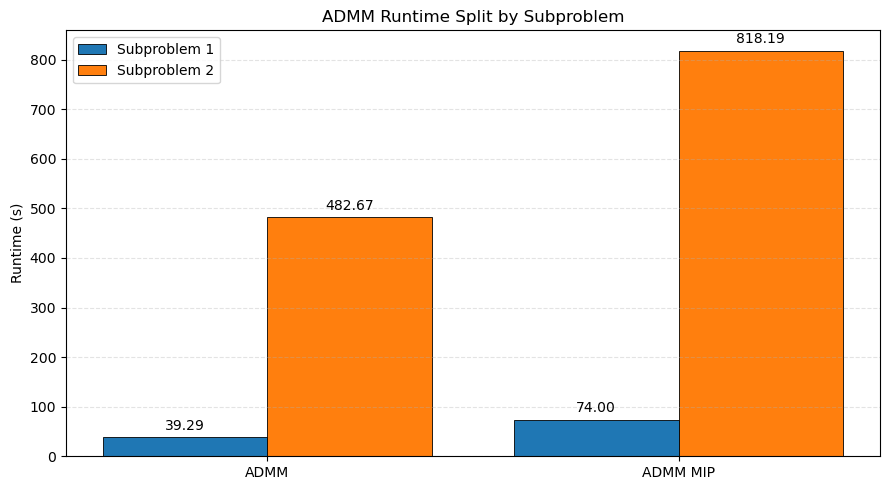

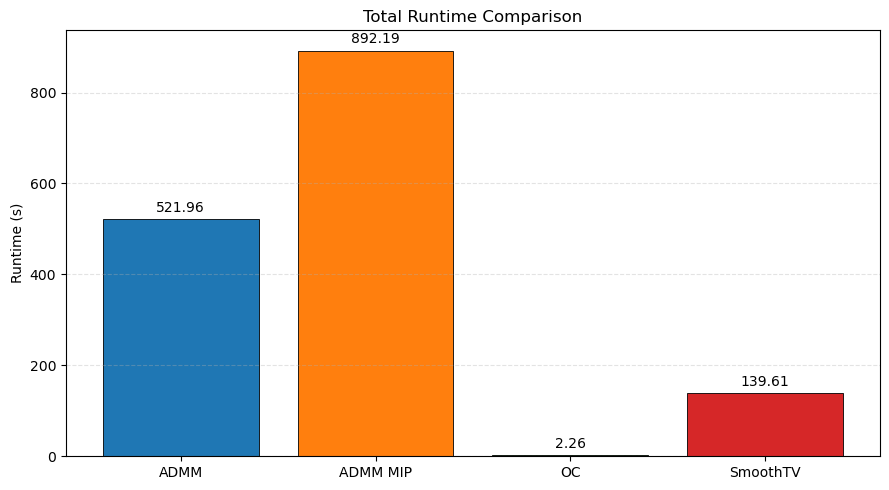

ADMM total runtime: 521.961 s
ADMM MIP total runtime: 892.194 s
OC total runtime: 2.264 s
SmoothTV total runtime: 139.614 s


In [59]:
# Runtime extraction
admm_runtime_sub1 = float(np.sum(admmcolin.trial(0).series.runtime_sub1))
admm_runtime_sub2 = float(np.sum(admmcolin.trial(0).series.runtime_sub2))
admm_runtime_total = admm_runtime_sub1 + admm_runtime_sub2

admm_mip_runtime_sub1 = float(np.sum(admmmip.trial(0).series.runtime_sub1))
admm_mip_runtime_sub2 = float(np.sum(admmmip.trial(0).series.runtime_sub2))
admm_mip_runtime_total = admm_mip_runtime_sub1 + admm_mip_runtime_sub2

fenics_runtime_total = float(
    getattr(fenics, "total_runtime", getattr(fenics, "runtime_total", np.nan))
)


# OC runtime loader (requested folder first, with fallback)
def _load_oc_runtime_total(r_value, mesh_size):
    candidate_roots = [
        Path("oc_method/OC_results_mew"),
        Path("oc_method/OC_results_new"),
    ]

    last_attempt = None
    for root in candidate_roots:
        candidate = root / f"{float(r_value):.2f}" / f"{int(mesh_size)}.h5"
        last_attempt = candidate
        if candidate.exists():
            with h5py.File(candidate, "r") as h5f:
                return float(h5f.attrs.get("runtime_total", np.nan)), candidate

    print(f"OC runtime file not found. Last tried: {last_attempt}")
    return np.nan, None


oc_runtime_total, oc_runtime_path = _load_oc_runtime_total(r, mesh_dim)
if oc_runtime_path is not None:
    print(f"Loaded OC runtime from: {oc_runtime_path}")


# -------- Plot 1: ADMM split runtimes (touching half-width bars) --------
methods = ["ADMM", "ADMM MIP"]
sub1_vals = np.array([admm_runtime_sub1, admm_mip_runtime_sub1], dtype=float)
sub2_vals = np.array([admm_runtime_sub2, admm_mip_runtime_sub2], dtype=float)

x = np.arange(len(methods), dtype=float)
bar_w = 0.40

fig, ax = plt.subplots(figsize=(9, 5))

bars_sub1 = ax.bar(
    x - bar_w / 2,
    sub1_vals,
    width=bar_w,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.6,
    label="Subproblem 1",
)

bars_sub2 = ax.bar(
    x + bar_w / 2,
    sub2_vals,
    width=bar_w,
    color="tab:orange",
    edgecolor="black",
    linewidth=0.6,
    label="Subproblem 2",
)

ax.bar_label(bars_sub1, fmt="%.2f", padding=3, fontsize=10)
ax.bar_label(bars_sub2, fmt="%.2f", padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Runtime (s)")
ax.set_title("ADMM Runtime Split by Subproblem")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


# -------- Plot 2: Total runtime comparison --------
total_labels = ["ADMM", "ADMM MIP", "OC", "SmoothTV"]
total_vals = np.array(
    [
        admm_runtime_total,
        admm_mip_runtime_total,
        oc_runtime_total,
        fenics_runtime_total,
    ],
    dtype=float,
)

fig, ax = plt.subplots(figsize=(9, 5))
bars_total = ax.bar(
    total_labels,
    total_vals,
    color=["tab:blue", "tab:orange", "tab:green", "tab:red"],
    edgecolor="black",
    linewidth=0.6,
)

ax.bar_label(bars_total, fmt="%.2f", padding=3, fontsize=10)
ax.set_ylabel("Runtime (s)")
ax.set_title("Total Runtime Comparison")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


print(f"ADMM total runtime: {admm_runtime_total:.3f} s")
print(f"ADMM MIP total runtime: {admm_mip_runtime_total:.3f} s")
print(f"OC total runtime: {oc_runtime_total:.3f} s")
print(f"SmoothTV total runtime: {fenics_runtime_total:.3f} s")

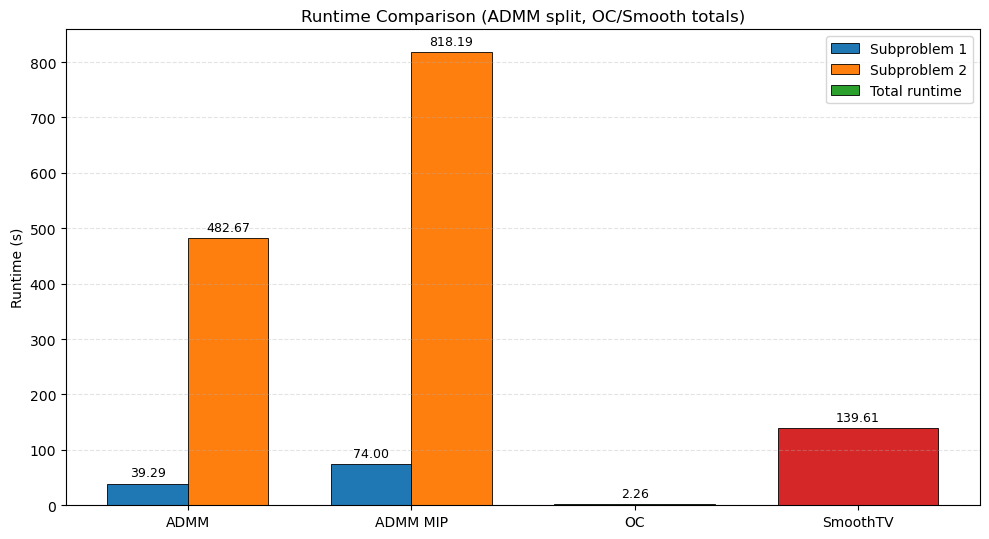

In [60]:
# Single combined runtime plot:
# - ADMM and ADMM MIP are split into touching half-bars (Sub1/Sub2)
# - OC and SmoothTV are shown as single total-runtime bars

# Recompute if needed (safe if already present)
admm_runtime_sub1 = float(np.sum(admmcolin.trial(0).series.runtime_sub1))
admm_runtime_sub2 = float(np.sum(admmcolin.trial(0).series.runtime_sub2))
admm_runtime_total = admm_runtime_sub1 + admm_runtime_sub2

admm_mip_runtime_sub1 = float(np.sum(admmmip.trial(0).series.runtime_sub1))
admm_mip_runtime_sub2 = float(np.sum(admmmip.trial(0).series.runtime_sub2))
admm_mip_runtime_total = admm_mip_runtime_sub1 + admm_mip_runtime_sub2

fenics_runtime_total = float(
    getattr(fenics, "total_runtime", getattr(fenics, "runtime_total", np.nan))
)

if "oc_runtime_total" not in globals() or np.isnan(oc_runtime_total):
    candidate_roots = [Path("oc_method/OC_results_mew"), Path("oc_method/OC_results_new")]
    oc_runtime_total = np.nan
    for root in candidate_roots:
        oc_path = root / f"{float(r):.2f}" / f"{int(mesh_dim)}.h5"
        if oc_path.exists():
            with h5py.File(oc_path, "r") as h5f:
                oc_runtime_total = float(h5f.attrs.get("runtime_total", np.nan))
            break

labels = ["ADMM", "ADMM MIP", "OC", "SmoothTV"]
x = np.arange(len(labels), dtype=float)
full_w = 0.72
half_w = full_w / 2.0

fig, ax = plt.subplots(figsize=(10, 5.5))

# Split bars for ADMM
admm_sub1_bar = ax.bar(
    x[0] - half_w / 2,
    admm_runtime_sub1,
    width=half_w,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.6,
    label="Subproblem 1",
)
admm_sub2_bar = ax.bar(
    x[0] + half_w / 2,
    admm_runtime_sub2,
    width=half_w,
    color="tab:orange",
    edgecolor="black",
    linewidth=0.6,
    label="Subproblem 2",
)

# Split bars for ADMM MIP
admm_mip_sub1_bar = ax.bar(
    x[1] - half_w / 2,
    admm_mip_runtime_sub1,
    width=half_w,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.6,
)
admm_mip_sub2_bar = ax.bar(
    x[1] + half_w / 2,
    admm_mip_runtime_sub2,
    width=half_w,
    color="tab:orange",
    edgecolor="black",
    linewidth=0.6,
)

# Single bars for OC and SmoothTV totals
oc_bar = ax.bar(
    x[2],
    oc_runtime_total,
    width=full_w,
    color="tab:green",
    edgecolor="black",
    linewidth=0.6,
    label="Total runtime",
)
smooth_bar = ax.bar(
    x[3],
    fenics_runtime_total,
    width=full_w,
    color="tab:red",
    edgecolor="black",
    linewidth=0.6,
)

# Labels on all bars
for bars in [admm_sub1_bar, admm_sub2_bar, admm_mip_sub1_bar, admm_mip_sub2_bar, oc_bar, smooth_bar]:
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Runtime (s)")
ax.set_title("Runtime Comparison (ADMM split, OC/Smooth totals)")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()